# ДЗ1. Анализ текстовой коллекции

В этом ноутбуке решается основная часть домашнего задания по курсу «Введение в информационный поиск».

Ноутбук устроен как короткий отчет: сначала мы загружаем коллекцию `WikIR en1k`, затем считаем базовые статистики, анализируем частоты слов и биграмм, проверяем законы Ципфа и Хипса, после чего сравниваем разные способы нормализации текста.

Основные этапы:
1. Загрузка и первичное изучение коллекции `WikIR en1k`
2. Базовые статистики коллекции
3. Частотный словарь слов и анализ стоп-слов
4. Графики по законам Ципфа и Хипса
5. Частотный словарь биграмм и критерии отбора
6. Морфологическая обработка: stemming, lemmatization, BERT tokenization
7. Сводное сравнение и выводы


## 1. Что нужно для запуска

Для основной части используем коллекцию `WikIR en1k`, которая в источниках проекта также называется `wikIR1k`.

В рабочей папке должны находиться:
- распакованный архив `wikIR1k`
- файл `stopwords_en.txt`

На текущем этапе нам нужен только `documents.csv`. Все ключевые выводы по каждому разделу уже оформлены в markdown-блоках сразу после вычислений и графиков.


In [1]:
from pathlib import Path
from collections import Counter
from itertools import chain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 20)


## 2. Поиск и загрузка `documents.csv`


In [2]:
ROOT = Path.cwd()
documents_candidates = sorted(ROOT.rglob("documents.csv"))

if not documents_candidates:
    raise FileNotFoundError(
        "Файл documents.csv не найден. Распакуй wikIR1k в рабочую папку проекта или в ее подпапку."
    )

DOCS_PATH = documents_candidates[0]
print(f"Найден файл: {DOCS_PATH}")
print("Файлы рядом с documents.csv:")
for path in sorted(DOCS_PATH.parent.iterdir())[:20]:
    print("-", path.name)


Найден файл: dz1/wikIR1k/wikIR1k/documents.csv
Файлы рядом с documents.csv:
- documents.csv
- test
- train
- validation


In [3]:
docs_df = pd.read_csv(DOCS_PATH)
print(f"Размер таблицы: {docs_df.shape}")
docs_df.head()


Размер таблицы: (99987, 2)


,id_right,text_right
0,0,these institutions are often described as stateless societies although several authors have defined them more specifically as distinct institutions based on non hierarchical or free associations a...
1,1,parents usually notice signs during the first three years of their child s life these signs often develop gradually though some children with autism reach their developmental milestones at a norma...
2,2,a planet like earth it is dimensionless and measured via an albedometer on a scale from 0 corresponding to a black body that absorbs all incident radiation to 1 corresponding to a body that reflec...
3,3,it is similar to the ancient greek letter alpha from which it derives the uppercase version consists of the two slanting sides of a triangle crossed in the middle by a horizontal bar the lowercase...
4,4,it is bordered by tennessee to the north georgia to the east florida and the gulf of mexico to the south and mississippi to the west alabama is the 30th largest by area and the 24th most populous ...


## 3. Первичное изучение структуры данных

В `documents.csv` у нас есть:
- `id_right` — идентификатор документа
- `text_right` — текст документа


In [4]:
print("Столбцы таблицы:")
for column in docs_df.columns:
    print(f"- {column}")

print()
docs_df.info()


Столбцы таблицы:
- id_right
- text_right

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99987 entries, 0 to 99986
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_right    99987 non-null  int64 
 1   text_right  99987 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [5]:
DOC_ID_COLUMN = "id_right"
TEXT_COLUMN = "text_right"

docs_df[[DOC_ID_COLUMN, TEXT_COLUMN]].head(5)


,id_right,text_right
0,0,these institutions are often described as stateless societies although several authors have defined them more specifically as distinct institutions based on non hierarchical or free associations a...
1,1,parents usually notice signs during the first three years of their child s life these signs often develop gradually though some children with autism reach their developmental milestones at a norma...
2,2,a planet like earth it is dimensionless and measured via an albedometer on a scale from 0 corresponding to a black body that absorbs all incident radiation to 1 corresponding to a body that reflec...
3,3,it is similar to the ancient greek letter alpha from which it derives the uppercase version consists of the two slanting sides of a triangle crossed in the middle by a horizontal bar the lowercase...
4,4,it is bordered by tennessee to the north georgia to the east florida and the gulf of mexico to the south and mississippi to the west alabama is the 30th largest by area and the 24th most populous ...


## 4. Базовое представление коллекции

По условию задания коллекция уже очищена, токенизирована и приведена к нижнему регистру.

Поэтому берем простое представление:
- список документов как списков токенов;
- единый список всех токенов коллекции.


In [6]:
documents = docs_df[TEXT_COLUMN].fillna("").astype(str).tolist()
tokenized_docs = [doc.split() for doc in documents]
all_tokens = list(chain.from_iterable(tokenized_docs))

print(f"Число документов: {len(tokenized_docs):,}")
print(f"Число токенов в коллекции: {len(all_tokens):,}")


Число документов: 99,987
Число токенов в коллекции: 19,963,076


In [7]:
sample_indices = [0, 1, 2]

for idx in sample_indices:
    print(f"Документ {idx}, id={docs_df.loc[idx, DOC_ID_COLUMN]}")
    print(tokenized_docs[idx][:40])
    print("Длина документа:", len(tokenized_docs[idx]))
    print()


Документ 0, id=0
['these', 'institutions', 'are', 'often', 'described', 'as', 'stateless', 'societies', 'although', 'several', 'authors', 'have', 'defined', 'them', 'more', 'specifically', 'as', 'distinct', 'institutions', 'based', 'on', 'non', 'hierarchical', 'or', 'free', 'associations', 'anarchism', 's', 'central', 'disagreement', 'with', 'other', 'ideologies', 'is', 'that', 'it', 'holds', 'the', 'state', 'to']
Длина документа: 200

Документ 1, id=1
['parents', 'usually', 'notice', 'signs', 'during', 'the', 'first', 'three', 'years', 'of', 'their', 'child', 's', 'life', 'these', 'signs', 'often', 'develop', 'gradually', 'though', 'some', 'children', 'with', 'autism', 'reach', 'their', 'developmental', 'milestones', 'at', 'a', 'normal', 'pace', 'before', 'worsening', 'autism', 'is', 'associated', 'with', 'a', 'combination']
Длина документа: 200

Документ 2, id=2
['a', 'planet', 'like', 'earth', 'it', 'is', 'dimensionless', 'and', 'measured', 'via', 'an', 'albedometer', 'on', 'a', 'sc

На этом этапе нужно вручную убедиться, что токены действительно разделены пробелами и дополнительная токенизация для исходной версии корпуса не нужна.


## 5. Базовые статистики коллекции


In [8]:
def compute_collection_stats(tokenized_docs):
    all_tokens_local = list(chain.from_iterable(tokenized_docs))
    unique_tokens_local = sorted(set(all_tokens_local))
    doc_lengths = [len(doc) for doc in tokenized_docs]

    stats = {
        "Число документов": len(tokenized_docs),
        "Размер коллекции в словах": len(all_tokens_local),
        "Средняя длина документа": np.mean(doc_lengths),
        "Число уникальных слов": len(unique_tokens_local),
        "Средняя длина слова": np.mean([len(token) for token in all_tokens_local]),
        "Средняя длина уникального слова": np.mean([len(token) for token in unique_tokens_local]),
    }

    return pd.DataFrame(
        {"Метрика": list(stats.keys()), "Значение": list(stats.values())}
    )


In [9]:
base_stats_df = compute_collection_stats(tokenized_docs)
base_stats_df["Значение"] = base_stats_df["Значение"].apply(
    lambda value: round(value, 4) if isinstance(value, (float, np.floating)) else value
)
base_stats_df


,Метрика,Значение
0,Число документов,9.998700e+04
1,Размер коллекции в словах,1.996308e+07
2,Средняя длина документа,1.996567e+02
3,Число уникальных слов,2.853760e+05
4,Средняя длина слова,4.693400e+00
5,Средняя длина уникального слова,7.523500e+00


## 6. Частотный словарь слов

Строим частотный список слов по всей коллекции.


In [10]:
word_counts = Counter(all_tokens)
frequency_df = pd.DataFrame(word_counts.items(), columns=["token", "frequency"])
frequency_df = frequency_df.sort_values("frequency", ascending=False).reset_index(drop=True)
frequency_df["rank"] = np.arange(1, len(frequency_df) + 1)
frequency_df.head(20)


,token,frequency,rank
0,the,1557812,1
1,of,881627,2
2,and,567768,3
3,in,515312,4
4,a,389090,5
5,to,343354,6
6,was,308940,7
7,is,267701,8
8,as,191301,9
9,were,142334,10


In [11]:
top30_df = frequency_df.head(30).copy()
top30_df


,token,frequency,rank
0,the,1557812,1
1,of,881627,2
2,and,567768,3
3,in,515312,4
4,a,389090,5
5,to,343354,6
6,was,308940,7
7,is,267701,8
8,as,191301,9
9,were,142334,10


Чтобы верхушка частотного списка читалась быстрее, удобно отдельно посмотреть на top-20 слов в виде графика.


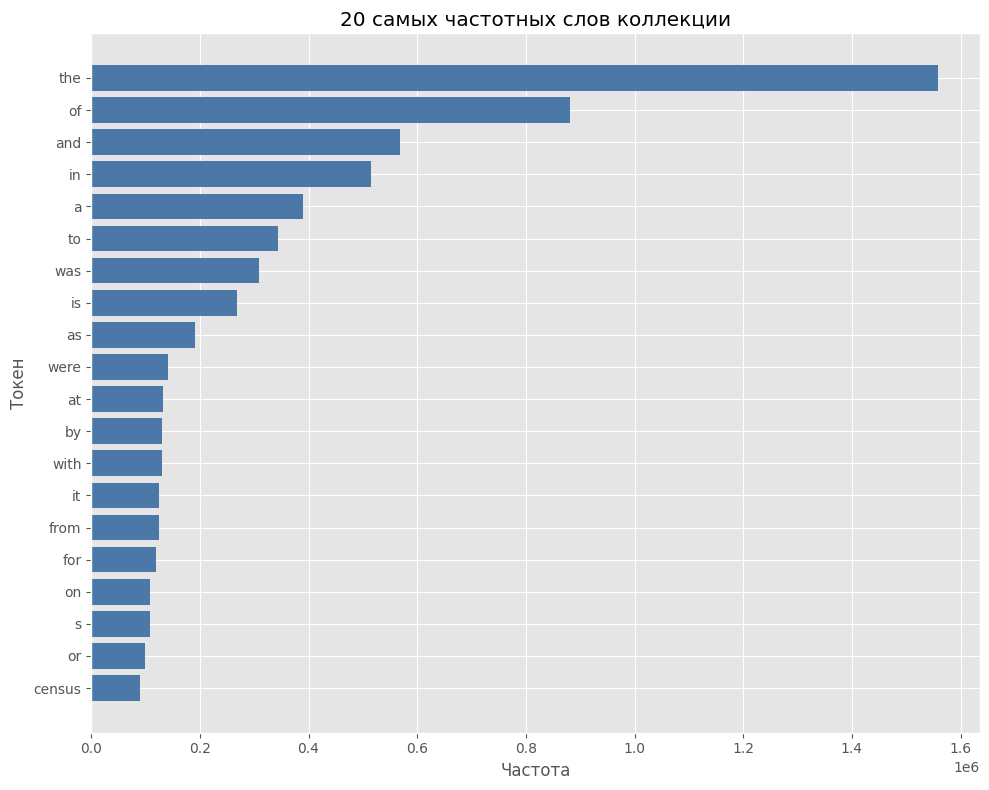

In [12]:
top20_plot_df = frequency_df.head(20).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top20_plot_df["token"], top20_plot_df["frequency"], color="#4C78A8")
plt.title("20 самых частотных слов коллекции")
plt.xlabel("Частота")
plt.ylabel("Токен")
plt.tight_layout()
plt.show()


Вверху частотного списка действительно доминируют служебные слова. При этом top-30 показывает и коллекционно-специфичные частотные токены: `census`, `population`, а также числовые токены `0` и `1`.


## 7. Анализ stopwords

Используем внешний список stopwords из задания, сохраненный в локальный файл `stopwords_en.txt`.


In [13]:
STOPWORDS_PATH = ROOT / "stopwords_en.txt"

if not STOPWORDS_PATH.exists():
    raise FileNotFoundError(
        "Файл stopwords_en.txt не найден. Положи его в корень проекта."
    )

with STOPWORDS_PATH.open("r", encoding="utf-8") as f:
    stopwords = {line.strip() for line in f if line.strip()}

print(f"Число stopwords в списке: {len(stopwords)}")
print(sorted(list(stopwords))[:20])


Число stopwords в списке: 127
['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below']


In [14]:
stopword_occurrences = sum(count for token, count in word_counts.items() if token in stopwords)
stopword_share = stopword_occurrences / len(all_tokens)

stopword_stats_df = pd.DataFrame(
    {
        "Метрика": [
            "Число stopword-вхождений",
            "Доля stopword-вхождений от всех токенов",
        ],
        "Значение": [
            stopword_occurrences,
            round(stopword_share, 4),
        ],
    }
)
stopword_stats_df


,Метрика,Значение
0,Число stopword-вхождений,8.101999e+06
1,Доля stopword-вхождений от всех токенов,4.058000e-01


Отдельный график помогает быстро увидеть, какую долю всей коллекции занимают stopwords и какая часть приходится на остальные токены.


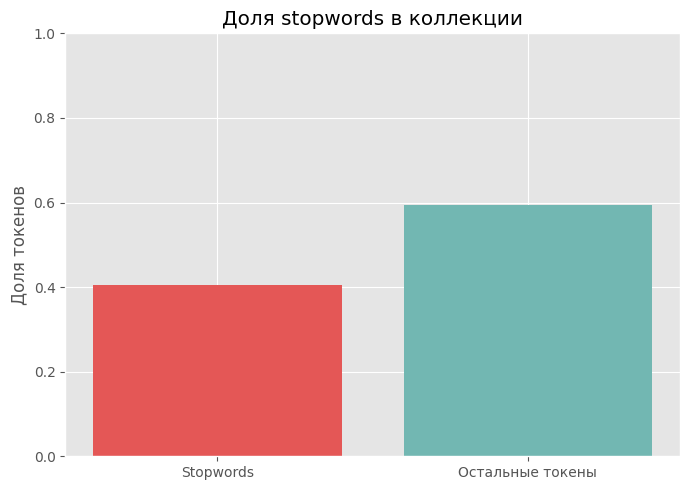

In [15]:
stopword_plot_df = pd.DataFrame(
    {
        "Категория": ["Stopwords", "Остальные токены"],
        "Доля": [stopword_share, 1 - stopword_share],
    }
)

plt.figure(figsize=(7, 5))
plt.bar(stopword_plot_df["Категория"], stopword_plot_df["Доля"], color=["#E45756", "#72B7B2"])
plt.title("Доля stopwords в коллекции")
plt.ylabel("Доля токенов")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [16]:
top30_stopwords_df = top30_df.copy()
top30_stopwords_df["is_stopword"] = top30_stopwords_df["token"].isin(stopwords)
top30_stopwords_df


,token,frequency,rank,is_stopword
0,the,1557812,1,True
1,of,881627,2,True
2,and,567768,3,True
3,in,515312,4,True
4,a,389090,5,True
5,to,343354,6,True
6,was,308940,7,True
7,is,267701,8,True
8,as,191301,9,True
9,were,142334,10,True


По фактическим результатам:
- в коллекции `8101999` stopword-вхождений, то есть около `40.58%` всех токенов;
- не все слова из top-30 входят в stopword list: среди исключений есть `census`, `population`, `0`, `1`;
- расширять stopword list словами `census` и `population` я бы не рекомендовал, потому что это содержательные доменные слова, а не служебная лексика;
- токены `0` и `1` скорее стоит рассматривать не как stopwords, а как отдельный вопрос нормализации чисел;
- токен `s` показывает, что исходный stopword list содержит спорные элементы и артефакты токенизации.


## 8. Закон Ципфа

Строим график зависимости частоты от ранга в log-log координатах.


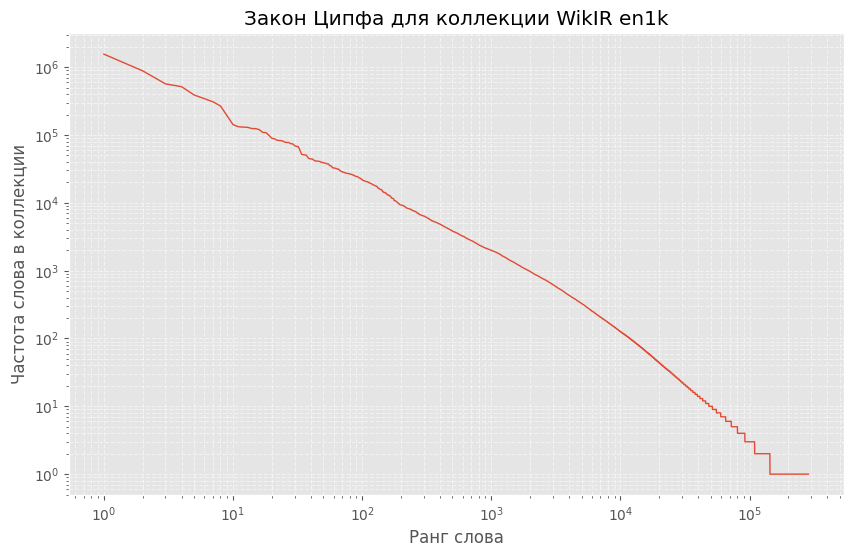

In [17]:
plt.figure(figsize=(10, 6))
plt.loglog(frequency_df["rank"], frequency_df["frequency"], linewidth=1)
plt.title("Закон Ципфа для коллекции WikIR en1k")
plt.xlabel("Ранг слова")
plt.ylabel("Частота слова в коллекции")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()


На таком графике для нашей коллекции ожидается типичная картина закона Ципфа: почти линейное поведение в log-log координатах, очень тяжелая голова распределения и длинный хвост редких слов. На голове заметно влияние служебных слов, а на верхних позициях среди содержательных токенов выделяются коллекционно-специфичные слова вроде `census` и `population`.


## 9. Закон Хипса

Чтобы не хранить значение после каждого токена, будем снимать точки графика через фиксированный шаг.


In [18]:
def compute_heaps_points(tokenized_docs, step=50_000):
    seen = set()
    token_counts = []
    vocab_sizes = []
    total_tokens = 0

    for doc in tokenized_docs:
        for token in doc:
            total_tokens += 1
            seen.add(token)

            if total_tokens % step == 0:
                token_counts.append(total_tokens)
                vocab_sizes.append(len(seen))

    if not token_counts or token_counts[-1] != total_tokens:
        token_counts.append(total_tokens)
        vocab_sizes.append(len(seen))

    return pd.DataFrame(
        {
            "tokens_seen": token_counts,
            "vocab_size": vocab_sizes,
        }
    )


In [19]:
heaps_df = compute_heaps_points(tokenized_docs, step=50_000)
heaps_df.head()


,tokens_seen,vocab_size
0,50000,9490
1,100000,14966
2,150000,19079
3,200000,22983
4,250000,26397


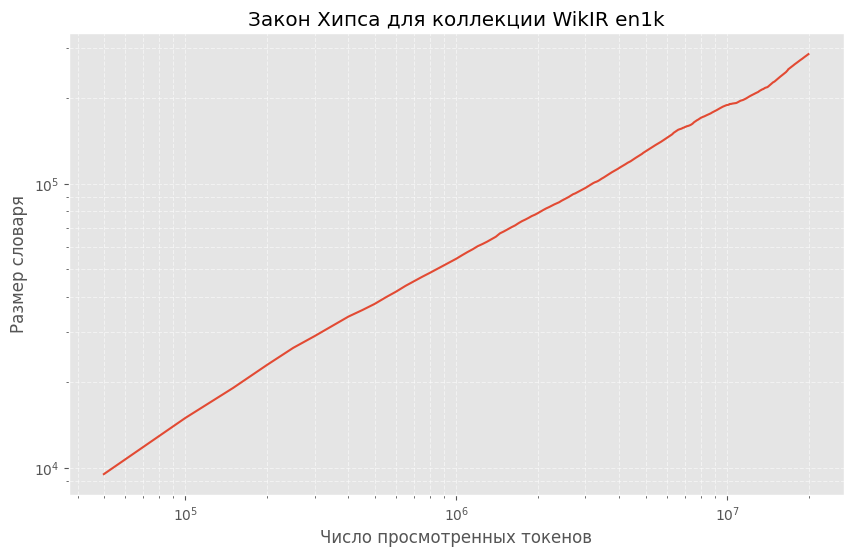

In [20]:
plt.figure(figsize=(10, 6))
plt.loglog(heaps_df["tokens_seen"], heaps_df["vocab_size"], linewidth=1.5)
plt.title("Закон Хипса для коллекции WikIR en1k")
plt.xlabel("Число просмотренных токенов")
plt.ylabel("Размер словаря")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()


Для нашей коллекции график Хипса должен показывать сублинейный рост словаря: число уникальных слов продолжает расти по мере просмотра корпуса, но скорость роста постепенно снижается. На финальной точке при `19963076` токенах словарь достигает `285376` уникальных слов.


## 10. Частотный словарь биграмм

Собираем биграммы как пары соседних токенов внутри документа. Между документами биграммы не строим.


In [21]:
def build_bigram_counter(tokenized_docs):
    bigram_counts = Counter()

    for doc in tokenized_docs:
        if len(doc) < 2:
            continue
        bigram_counts.update(zip(doc, doc[1:]))

    return bigram_counts


In [22]:
bigram_counts = build_bigram_counter(tokenized_docs)
print(f"Число уникальных биграмм: {len(bigram_counts):,}")


Число уникальных биграмм: 4,083,973


In [23]:
bigram_df = pd.DataFrame(
    [(left, right, freq) for (left, right), freq in bigram_counts.items()],
    columns=["token_1", "token_2", "frequency"],
)
bigram_df = bigram_df.sort_values("frequency", ascending=False).reset_index(drop=True)
bigram_df.head(30)


,token_1,token_2,frequency
0,of,the,265328
1,in,the,147038
2,to,the,93293
3,the,population,66719
4,there,were,57311
5,at,the,56370
6,and,the,47362
7,it,is,41907
8,on,the,37815
9,united,states,37437


По таблице видно, что сырая частота сама по себе плохо отделяет полезные биграммы от служебных. Это наглядно проявляется и на графике top-20 биграмм.


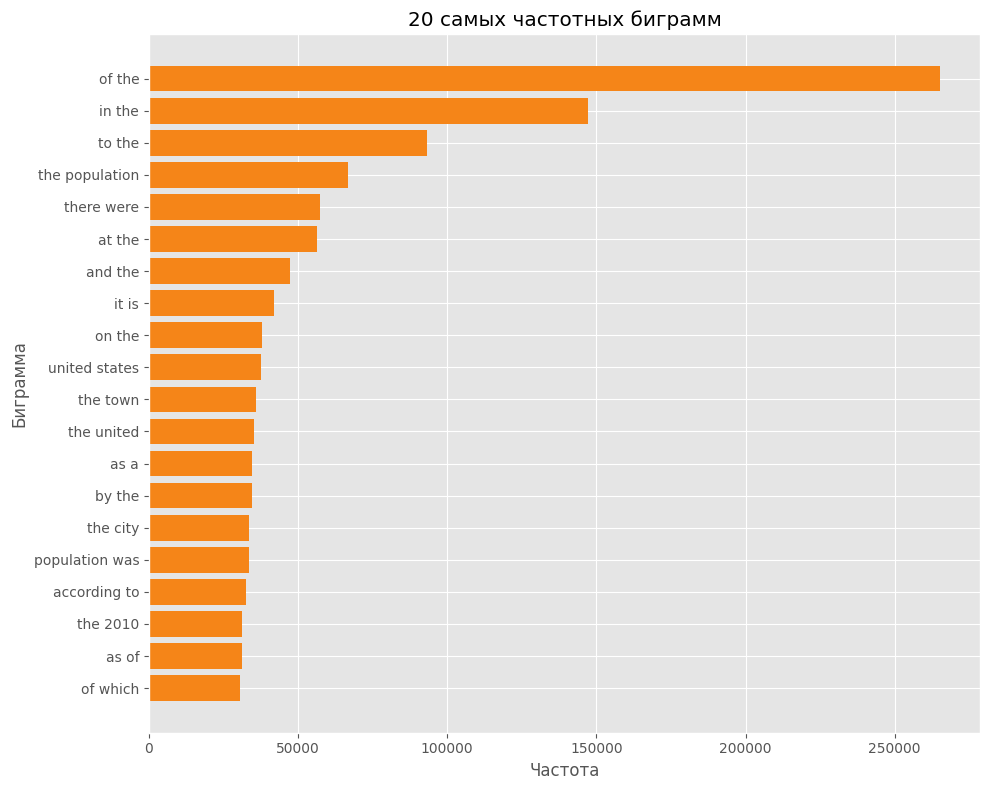

In [24]:
top20_bigrams_plot_df = bigram_df.head(20).copy()
top20_bigrams_plot_df["bigram"] = top20_bigrams_plot_df["token_1"] + " " + top20_bigrams_plot_df["token_2"]
top20_bigrams_plot_df = top20_bigrams_plot_df.iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top20_bigrams_plot_df["bigram"], top20_bigrams_plot_df["frequency"], color="#F58518")
plt.title("20 самых частотных биграмм")
plt.xlabel("Частота")
plt.ylabel("Биграмма")
plt.tight_layout()
plt.show()


## 11. Какие биграммы стоит хранить в индексе

Обычной частоты недостаточно: наверху списка часто оказываются комбинации служебных слов. Поэтому добавим простую формализацию через частоту, stopwords и меру связанности `PMI`.


In [25]:
TOTAL_TOKENS = len(all_tokens)
TOTAL_BIGRAMS = sum(max(len(doc) - 1, 0) for doc in tokenized_docs)

def compute_pmi(bigram, bigram_freq, unigram_counts, total_tokens, total_bigrams):
    left, right = bigram
    p_xy = bigram_freq / total_bigrams
    p_x = unigram_counts[left] / total_tokens
    p_y = unigram_counts[right] / total_tokens
    return np.log2(p_xy / (p_x * p_y))


In [26]:
candidate_rows = []

for bigram, freq in bigram_counts.items():
    left, right = bigram
    pmi = compute_pmi(bigram, freq, word_counts, TOTAL_TOKENS, TOTAL_BIGRAMS)
    both_stopwords = left in stopwords and right in stopwords

    candidate_rows.append(
        {
            "token_1": left,
            "token_2": right,
            "frequency": freq,
            "pmi": pmi,
            "both_stopwords": both_stopwords,
        }
    )

bigram_candidates_df = pd.DataFrame(candidate_rows)
bigram_candidates_df = bigram_candidates_df.sort_values(
    ["frequency", "pmi"], ascending=[False, False]
).reset_index(drop=True)
bigram_candidates_df.head(20)


,token_1,token_2,frequency,pmi,both_stopwords
0,of,the,265328,1.954594,True
1,in,the,147038,1.877728,True
2,to,the,93293,1.807129,True
3,the,population,66719,3.384295,False
4,there,were,57311,6.769194,True
5,at,the,56370,2.453002,True
6,and,the,47362,0.103485,True
7,it,is,41907,4.657485,True
8,on,the,37815,2.157043,True
9,united,states,37437,8.776035,False


In [27]:
selected_bigrams_df = bigram_candidates_df[
    (bigram_candidates_df["frequency"] >= 20)
    & (~bigram_candidates_df["both_stopwords"])
    & (bigram_candidates_df["pmi"] >= 3)
].copy()

selected_bigrams_df.head(30)


,token_1,token_2,frequency,pmi,both_stopwords
3,the,population,66719,3.384295,False
9,united,states,37437,8.776035,False
10,the,town,35807,3.307702,False
11,the,united,35082,3.453182,False
14,the,city,33539,3.074738,False
15,population,was,33493,4.724180,False
16,according,to,32694,5.865344,False
17,the,2010,31349,3.308994,False
21,2010,census,28839,7.311037,False
23,area,of,28290,3.435062,False


В нашей коллекции получилось `4083973` уникальных биграмм. Верхушка списка по сырой частоте сильно засорена служебными сочетаниями вроде `of the`, `in the`, `to the`, но уже там же появляются полезные единицы вроде `united states`, `according to`, `2010 census`.

Один из разумных критериев отбора биграмм для словаря индекса:
- биграмма встречается не слишком редко, например `frequency >= 20`;
- биграмма не состоит целиком из stopwords;
- у биграммы есть достаточно высокая связность, например `PMI >= 3`.

Такой критерий в нашей коллекции сохраняет содержательные сочетания вроде `united states`, `2010 census`, `census bureau`, `population density`, `racial makeup`, `square mile` и одновременно отфильтровывает шумовые служебные биграммы вроде `of the`.


## 12. Подготовка к морфологической обработке

Для этой части нужны:
- `nltk` с `PorterStemmer`
- `spacy` и модель `en_core_web_sm`
- `transformers` и токенизатор `bert-base-uncased`

Если модель spaCy не установлена, ее нужно скачать командой:
`python -m spacy download en_core_web_sm`

Дальше будем считать статистики потоково, чтобы не хранить в памяти все преобразованные версии корпуса одновременно.


In [28]:
from nltk.stem import PorterStemmer
import spacy
from transformers import AutoTokenizer


ModuleNotFoundError: No module named 'nltk'

In [ ]:
def analyze_transformed_docs(name, transformed_docs_iterable, sample_size=3):
    doc_count = 0
    total_tokens = 0
    total_token_length = 0
    total_doc_length = 0
    vocabulary = set()
    samples = []

    for doc in transformed_docs_iterable:
        if doc_count < sample_size:
            samples.append(doc[:40])

        doc_count += 1
        doc_len = len(doc)
        total_doc_length += doc_len
        total_tokens += doc_len
        total_token_length += sum(len(token) for token in doc)
        vocabulary.update(doc)

    row = {
        "Версия": name,
        "Число документов": doc_count,
        "Размер коллекции в токенах": total_tokens,
        "Средняя длина документа": round(total_doc_length / doc_count, 4),
        "Число уникальных токенов": len(vocabulary),
        "Средняя длина токена": round(total_token_length / total_tokens, 4),
        "Средняя длина уникального токена": round(
            sum(len(token) for token in vocabulary) / len(vocabulary), 4
        ),
    }

    return row, samples


def build_samples_comparison(samples_before, samples_after, title):
    rows = []
    for idx, (before, after) in enumerate(zip(samples_before, samples_after), start=1):
        rows.append(
            {
                "Пример": idx,
                "Исходные токены": " ".join(before[:20]),
                title: " ".join(after[:20]),
            }
        )
    return pd.DataFrame(rows)


## 13. Stemming через PorterStemmer


In [ ]:
stemmer = PorterStemmer()

def iter_stemmed_docs(tokenized_docs):
    for doc in tokenized_docs:
        yield [stemmer.stem(token) for token in doc]


In [ ]:
stemmed_stats_row, stemmed_samples = analyze_transformed_docs(
    "Стемминг (Porter)", iter_stemmed_docs(tokenized_docs)
)
stemmed_stats_row


In [ ]:
build_samples_comparison(
    [doc[:40] for doc in tokenized_docs[:3]],
    stemmed_samples,
    "После stemming",
)


## 14. Lemmatization через spaCy

Лемматизация выполняется по исходным текстам документов. Это более тяжелый этап, чем stemming, поэтому он может работать заметно дольше.

Важно: `spaCy` использует собственную токенизацию, поэтому число токенов после lemmatization может немного отличаться от исходной версии коллекции.


In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])

def iter_lemmatized_docs(documents, nlp, batch_size=128):
    for doc in nlp.pipe(documents, batch_size=batch_size):
        yield [token.lemma_ for token in doc]


In [ ]:
lemmatized_stats_row, lemmatized_samples = analyze_transformed_docs(
    "Лемматизация (spaCy)", iter_lemmatized_docs(documents, nlp)
)
lemmatized_stats_row


In [ ]:
build_samples_comparison(
    [doc[:40] for doc in tokenized_docs[:3]],
    lemmatized_samples,
    "После lemmatization",
)


## 15. BERT tokenization

Здесь обычные слова разбиваются на подслова `WordPiece`, поэтому результат уже нельзя напрямую трактовать как набор словоформ.


In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def iter_bert_tokenized_docs(documents, tokenizer):
    for doc in documents:
        yield tokenizer.tokenize(doc)


In [ ]:
bert_stats_row, bert_samples = analyze_transformed_docs(
    "BERT-токенизация", iter_bert_tokenized_docs(documents, bert_tokenizer)
)
bert_stats_row


In [ ]:
build_samples_comparison(
    [doc[:40] for doc in tokenized_docs[:3]],
    bert_samples,
    "После BERT tokenization",
)


## 16. Сводная таблица по всем версиям коллекции


In [ ]:
original_stats_row, _ = analyze_transformed_docs("Исходная коллекция", tokenized_docs)

comparison_stats_df = pd.DataFrame(
    [
        original_stats_row,
        stemmed_stats_row,
        lemmatized_stats_row,
        bert_stats_row,
    ]
)
comparison_stats_df


После сводной таблицы удобно отдельно сравнить размеры словаря и среднюю длину документа для разных версий корпуса.


In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(comparison_stats_df["Версия"], comparison_stats_df["Число уникальных токенов"], color="#54A24B")
plt.title("Размер словаря в разных версиях коллекции")
plt.ylabel("Число уникальных токенов")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(comparison_stats_df["Версия"], comparison_stats_df["Средняя длина документа"], color="#B279A2")
plt.title("Средняя длина документа в разных версиях коллекции")
plt.ylabel("Число токенов в документе")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 17. Итоговые выводы по основной части

По полному прогону коллекции уже видны основные эффекты:
- `PorterStemmer` уменьшает словарь с `285376` до `235971` уникальных токенов, то есть примерно на `17.31%`.
- `spaCy`-лемматизация уменьшает словарь до `264450`, то есть примерно на `7.33%`.
- `BERT`-токенизация уменьшает число уникальных токенов до `27426`, но это связано с фиксированным subword-словарем модели, а не с классической нормализацией слов.
- средняя длина документа после `BERT`-токенизации растет с `199.6567` до `219.3429`, то есть примерно на `9.86%`, потому что часть слов распадается на несколько подслов.

Из этого следует:
- для классического информационного поиска stemming и lemmatization полезны именно как способы умеренного сжатия словаря;
- stemming агрессивнее и сильнее сжимает словарь, но хуже сохраняет нормальную словоформу;
- lemmatization аккуратнее с языковой точки зрения, но дает более слабое сжатие;
- BERT-токены нельзя напрямую сравнивать с обычными словами при интерпретации статистик коллекции.
